In [1]:
# LEVEL 1 — DATA INGESTION & QA
# executable gate 


import pandas as pd
from pathlib import Path

# ---- locate data ----
DATA_PATH = Path.cwd().parents[0] / "data" / "raw" / "311_NYPD_2024_01_raw.csv"
df = pd.read_csv(DATA_PATH)

# ---- critical columns ----
CRITICAL_COLS = [
    "unique_key",
    "created_date",
    "closed_date",
    "agency",
    "complaint_type",
    "status",
    "incident_zip",
]

# ---- schema checks ----
missing_cols = [c for c in CRITICAL_COLS if c not in df.columns]
duplicate_ids = df["unique_key"].duplicated().any() if "unique_key" in df.columns else True

# ---- parse timestamps (force tz-naive UTC) ----
for c in ["created_date", "closed_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True).dt.tz_localize(None)

unparseable_created = df["created_date"].isna().sum() if "created_date" in df.columns else len(df)

# ---- completeness ----
null_closed_pct = df["closed_date"].isna().mean() if "closed_date" in df.columns else 1.0

# missing days
if "created_date" in df.columns:
    days = df["created_date"].dt.normalize()
    missing_days = pd.date_range(days.min(), days.max()).difference(days.unique())
    missing_days_count = len(missing_days)
else:
    missing_days_count = -1

# ---- reconciliation ----
closed_without_date = (
    ((df["status"] == "Closed") & (df["closed_date"].isna())).sum()
    if set(["status", "closed_date"]).issubset(df.columns)
    else len(df)
)

closed_before_created = (
    (df["closed_date"] < df["created_date"]).sum()
    if set(["created_date", "closed_date"]).issubset(df.columns)
    else len(df)
)

# ---- anomaly pre-screen ----
if set(["created_date", "closed_date"]).issubset(df.columns):
    resolution_days = (df["closed_date"] - df["created_date"]).dt.total_seconds() / 86400
    long_resolutions = (resolution_days > 7).sum()
else:
    long_resolutions = -1

now_utc_naive = pd.Timestamp.utcnow().tz_localize(None)

future_created = (
    (df["created_date"] > now_utc_naive).sum()
    if "created_date" in df.columns
    else -1
)

# ---- evaluate ----
results = {
    "schema_missing_critical_columns": "FAIL" if missing_cols else "PASS",
    "duplicate_unique_key": "FAIL" if duplicate_ids else "PASS",
    "unparseable_created_date": "FAIL" if unparseable_created > 0 else "PASS",
    "null_closed_date_pct_gt_20": "WARN" if null_closed_pct > 0.20 else "PASS",
    "missing_created_date_days": "WARN" if missing_days_count > 0 else "PASS",
    "closed_without_closed_date": "FAIL" if closed_without_date > 0 else "PASS",
    "closed_before_created_date": "FAIL" if closed_before_created > 0 else "PASS",
    "resolution_over_7_days": "WARN" if long_resolutions > 0 else "PASS",
    "future_created_dates": "FAIL" if future_created > 0 else "PASS",
}

summary = (
    pd.DataFrame({"check": results.keys(), "result": results.values()})
    .sort_values("result")
    .reset_index(drop=True)
)

overall = (
    "FAIL" if (summary["result"] == "FAIL").any()
    else "WARN" if (summary["result"] == "WARN").any()
    else "PASS"
)

print(f"LEVEL 1 QA — OVERALL STATUS: {overall}")
summary


LEVEL 1 QA — OVERALL STATUS: WARN


,check,result
0,schema_missing_critical_columns,PASS
1,duplicate_unique_key,PASS
2,unparseable_created_date,PASS
3,null_closed_date_pct_gt_20,PASS
4,missing_created_date_days,PASS
5,closed_without_closed_date,PASS
6,closed_before_created_date,PASS
7,future_created_dates,PASS
8,resolution_over_7_days,WARN


In [2]:
# LEVEL 2 — SETUP 

df_lvl2 = df.copy()

baseline_start = "2024-01-01"
baseline_end   = "2024-01-15"
post_start     = "2024-01-16"
post_end       = "2024-01-31"

df_lvl2["period"] = "other"

df_lvl2.loc[
    (df_lvl2["created_date"] >= baseline_start) &
    (df_lvl2["created_date"] <= baseline_end),
    "period"
] = "baseline"

df_lvl2.loc[
    (df_lvl2["created_date"] >= post_start) &
    (df_lvl2["created_date"] <= post_end),
    "period"
] = "post"

df_lvl2 = df_lvl2[df_lvl2["period"].isin(["baseline", "post"])]

df_lvl2["resolution_days"] = (
    df_lvl2["closed_date"] - df_lvl2["created_date"]
).dt.total_seconds() / 86400


In [3]:
# LEVEL 2 — DRIVER ISOLATION
# By complaint type

complaint_summary = (
    df_lvl2
    .groupby(["period", "complaint_type"])
    .agg(
        requests=("unique_key", "count"),
        avg_resolution_days=("resolution_days", "mean")
    )
    .reset_index()
)

# pivot for comparison
complaint_pivot = complaint_summary.pivot(
    index="complaint_type",
    columns="period",
    values=["requests", "avg_resolution_days"]
)

complaint_pivot.head(10)


requests         avg_resolution_days          
period                    baseline    post            baseline      post
complaint_type                                                          
Abandoned Vehicle           2843.0  2639.0            0.151206  0.147271
Animal-Abuse                 291.0   353.0            0.107049  0.118497
Bike/Roller/Skate Chronic   1080.0  1063.0            0.015786  0.012064
Blocked Driveway            6420.0  7044.0            0.122100  0.115345
Disorderly Youth               NaN     2.0                 NaN  0.186632
Drinking                      49.0    67.0            0.058621  0.058170
Drug Activity                605.0   678.0            0.038930  0.033520
Encampment                   881.0   771.0            0.039680  0.038542
Graffiti                      18.0    22.0            0.045619  0.038298
Illegal Fireworks             48.0    10.0            0.035435  0.060098

In [4]:
# LEVEL 2 — WEEKDAY VS WEEKEND

df_lvl2["is_weekend"] = df_lvl2["created_date"].dt.weekday >= 5

weekday_summary = (
    df_lvl2
    .groupby(["period", "is_weekend"])
    .agg(
        requests=("unique_key", "count"),
        avg_resolution_days=("resolution_days", "mean")
    )
    .reset_index()
)

weekday_summary


,period,is_weekend,requests,avg_resolution_days
0,baseline,False,31273,0.092915
1,baseline,True,13773,0.079776
2,post,False,35049,0.083290
3,post,True,13371,0.070332


In [5]:
# Level 3.0 — KPI Setup 

df_lvl3 = df_lvl2.copy()

# --- KPI framework parameters (Level 3) ---
SLA_DAYS = 7
ROLLING_DAYS = 7
TOP_N_CATEGORIES = 10

# Checkpoints: weekly review cadence for "decision checkpoints"
CHECKPOINT_FREQ = "W-MON"  # weekly, Mondays 

# Alert thresholds (baseline-driven defaults)
THRESHOLDS = {
    "volume_warn_pct": 0.10,
    "volume_alert_pct": 0.20,

    "res_warn_abs_days": 0.5,
    "res_alert_abs_days": 1.0,
    "res_warn_pct": 0.10,
    "res_alert_pct": 0.20,

    "sla_warn_pp": 0.03,   # percentage points as proportion (3%)
    "sla_alert_pp": 0.05,  # 5%

    "close_warn_pp": 0.02,  # 2%
    "close_alert_pp": 0.05, # 5%
}

df_lvl3["created_day"] = df_lvl3["created_date"].dt.floor("D")

# Closed flag for close-rate KPI
df_lvl3["is_closed"] = df_lvl3["closed_date"].notna()

# SLA compliance for "resolved within threshold" KPI
# Only for closed cases; open cases are treated as not meeting SLA for operational monitoring.
df_lvl3["within_sla_7d"] = df_lvl3["is_closed"] & (df_lvl3["resolution_days"] <= SLA_DAYS)

print("Level 3 setup complete.")


Level 3 setup complete.


In [6]:
# Level 3.1 — Daily KPI Table (overall)

daily_kpis = (
    df_lvl3
    .groupby(["created_day", "period"])
    .agg(
        requests=("unique_key", "count"),
        avg_resolution_days=("resolution_days", "mean"),
        close_rate=("is_closed", "mean"),
        pct_within_sla=("within_sla_7d", "mean"),
    )
    .reset_index()
    .sort_values(["period", "created_day"])
)

# Rolling window smoothing (by period)
daily_kpis["requests_roll"] = (
    daily_kpis
    .groupby("period")["requests"]
    .transform(lambda s: s.rolling(ROLLING_DAYS, min_periods=3).mean())
)

daily_kpis["avg_res_roll"] = (
    daily_kpis
    .groupby("period")["avg_resolution_days"]
    .transform(lambda s: s.rolling(ROLLING_DAYS, min_periods=3).mean())
)

daily_kpis["close_rate_roll"] = (
    daily_kpis
    .groupby("period")["close_rate"]
    .transform(lambda s: s.rolling(ROLLING_DAYS, min_periods=3).mean())
)

daily_kpis["pct_within_sla_roll"] = (
    daily_kpis
    .groupby("period")["pct_within_sla"]
    .transform(lambda s: s.rolling(ROLLING_DAYS, min_periods=3).mean())
)

daily_kpis.head(10)


,created_day,period,requests,avg_resolution_days,close_rate,pct_within_sla,requests_roll,avg_res_roll,close_rate_roll,pct_within_sla_roll
0,2024-01-01,baseline,459,0.072756,1.0,1.000000,NaN,NaN,NaN,NaN
1,2024-01-02,baseline,3364,0.107651,1.0,0.999405,NaN,NaN,NaN,NaN
2,2024-01-03,baseline,3450,0.087059,1.0,1.000000,2424.333333,0.089156,1.0,0.999802
3,2024-01-04,baseline,3496,0.084199,1.0,1.000000,2692.250000,0.087916,1.0,0.999851
4,2024-01-05,baseline,3498,0.091202,1.0,1.000000,2853.400000,0.088573,1.0,0.999881
5,2024-01-06,baseline,3525,0.072855,1.0,1.000000,2965.333333,0.085954,1.0,0.999901
6,2024-01-07,baseline,3199,0.084872,1.0,1.000000,2998.714286,0.085799,1.0,0.999915
7,2024-01-08,baseline,3499,0.096013,1.0,1.000000,3433.000000,0.089122,1.0,0.999915
8,2024-01-09,baseline,2988,0.086792,1.0,1.000000,3379.285714,0.086142,1.0,1.000000
9,2024-01-10,baseline,3386,0.079713,1.0,1.000000,3370.142857,0.085092,1.0,1.000000


In [7]:
# Level 3.2 — Baseline Anchors ("normal")

baseline = daily_kpis[daily_kpis["period"] == "baseline"].copy()

baseline_anchors = {
    "requests_roll_mean": baseline["requests_roll"].mean(),
    "avg_res_roll_mean": baseline["avg_res_roll"].mean(),
    "close_rate_roll_mean": baseline["close_rate_roll"].mean(),
    "pct_within_sla_roll_mean": baseline["pct_within_sla_roll"].mean(),
}

baseline_anchors


{'requests_roll_mean': np.float64(3140.216865079365),
 'avg_res_roll_mean': np.float64(0.0882600798390152),
 'close_rate_roll_mean': np.float64(1.0),
 'pct_within_sla_roll_mean': np.float64(0.9999255168675263)}

In [8]:
# Level 3.3 — Category Volume KPI (top categories by baseline)

# Identifying top categories by baseline volume (so monitoring focuses on meaningful drivers)
baseline_cat_counts = (
    df_lvl3[df_lvl3["period"] == "baseline"]
    .groupby("complaint_type")
    .agg(requests=("unique_key", "count"))
    .reset_index()
    .sort_values("requests", ascending=False)
)

top_categories = baseline_cat_counts["complaint_type"].head(TOP_N_CATEGORIES).tolist()
top_categories[:10], len(top_categories)


(['Illegal Parking',
  'Noise - Residential',
  'Blocked Driveway',
  'Abandoned Vehicle',
  'Noise - Commercial',
  'Noise - Street/Sidewalk',
  'Bike/Roller/Skate Chronic',
  'Noise - Vehicle',
  'Encampment',
  'Non-Emergency Police Matter'],
 10)

In [9]:
# Daily category volume for top categories + rolling
daily_cat_volume = (
    df_lvl3[df_lvl3["complaint_type"].isin(top_categories)]
    .groupby(["created_day", "period", "complaint_type"])
    .agg(requests=("unique_key", "count"))
    .reset_index()
    .sort_values(["complaint_type", "period", "created_day"])
)

daily_cat_volume["requests_roll"] = (
    daily_cat_volume
    .groupby(["period", "complaint_type"])["requests"]
    .transform(lambda s: s.rolling(ROLLING_DAYS, min_periods=3).mean())
)

daily_cat_volume.head(10)


,created_day,period,complaint_type,requests,requests_roll
0,2024-01-01,baseline,Abandoned Vehicle,7,NaN
10,2024-01-02,baseline,Abandoned Vehicle,273,NaN
20,2024-01-03,baseline,Abandoned Vehicle,256,178.666667
30,2024-01-04,baseline,Abandoned Vehicle,278,203.500000
40,2024-01-05,baseline,Abandoned Vehicle,227,208.200000
50,2024-01-06,baseline,Abandoned Vehicle,157,199.666667
60,2024-01-07,baseline,Abandoned Vehicle,174,196.000000
70,2024-01-08,baseline,Abandoned Vehicle,266,233.000000
80,2024-01-09,baseline,Abandoned Vehicle,204,223.142857
90,2024-01-10,baseline,Abandoned Vehicle,231,219.571429


In [10]:
# Level 3.4 — Alert Logic (WARN / ALERT) + Decision Checkpoints

def classify_alerts(row, anchors, t):
    """
    Returns a dict of alert flags for key KPIs using baseline anchors.
    Uses rolling metrics (smoothed) when available, else falls back to raw.
    """
    req = row["requests_roll"] if pd.notna(row["requests_roll"]) else row["requests"]
    res = row["avg_res_roll"] if pd.notna(row["avg_res_roll"]) else row["avg_resolution_days"]
    cr  = row["close_rate_roll"] if pd.notna(row["close_rate_roll"]) else row["close_rate"]
    sla = row["pct_within_sla_roll"] if pd.notna(row["pct_within_sla_roll"]) else row["pct_within_sla"]

    # Baseline anchors
    req0 = anchors["requests_roll_mean"]
    res0 = anchors["avg_res_roll_mean"]
    cr0  = anchors["close_rate_roll_mean"]
    sla0 = anchors["pct_within_sla_roll_mean"]

    out = {}

    # Volume alerts (higher is concern)
    if req0 and pd.notna(req):
        pct_up = (req - req0) / req0
        out["volume_alert"] = pct_up >= t["volume_alert_pct"]
        out["volume_warn"]  = (pct_up >= t["volume_warn_pct"]) and not out["volume_alert"]
    else:
        out["volume_alert"] = False
        out["volume_warn"]  = False

    # Resolution alerts (higher is concern)
    if pd.notna(res) and pd.notna(res0):
        abs_up = res - res0
        pct_up = (res - res0) / res0 if res0 else 0.0

        alert = (abs_up >= t["res_alert_abs_days"]) or (pct_up >= t["res_alert_pct"])
        warn  = (abs_up >= t["res_warn_abs_days"]) or (pct_up >= t["res_warn_pct"])
        out["res_alert"] = bool(alert)
        out["res_warn"]  = bool(warn and not alert)
    else:
        out["res_alert"] = False
        out["res_warn"]  = False

    # SLA alerts (lower is concern)
    if pd.notna(sla) and pd.notna(sla0):
        drop = sla0 - sla
        out["sla_alert"] = drop >= t["sla_alert_pp"]
        out["sla_warn"]  = (drop >= t["sla_warn_pp"]) and not out["sla_alert"]
    else:
        out["sla_alert"] = False
        out["sla_warn"]  = False

    # Close rate alerts (lower is concern)
    if pd.notna(cr) and pd.notna(cr0):
        drop = cr0 - cr
        out["close_alert"] = drop >= t["close_alert_pp"]
        out["close_warn"]  = (drop >= t["close_warn_pp"]) and not out["close_alert"]
    else:
        out["close_alert"] = False
        out["close_warn"]  = False

    # Overall status (simple severity max)
    if any([out["volume_alert"], out["res_alert"], out["sla_alert"], out["close_alert"]]):
        out["overall_status"] = "ALERT"
    elif any([out["volume_warn"], out["res_warn"], out["sla_warn"], out["close_warn"]]):
        out["overall_status"] = "WARN"
    else:
        out["overall_status"] = "OK"

    return out


import pandas as pd

post_daily = daily_kpis[daily_kpis["period"] == "post"].copy()

alerts = post_daily.apply(
    lambda r: pd.Series(classify_alerts(r, baseline_anchors, THRESHOLDS)),
    axis=1
)

post_daily_alerted = pd.concat([post_daily.reset_index(drop=True), alerts.reset_index(drop=True)], axis=1)

# Decision checkpoints: weekly (Mon) summary using rolling KPIs + worst status in that window
checkpoint = (
    post_daily_alerted
    .set_index("created_day")
    .resample(CHECKPOINT_FREQ)
    .agg(
        requests_roll=("requests_roll", "mean"),
        avg_res_roll=("avg_res_roll", "mean"),
        close_rate_roll=("close_rate_roll", "mean"),
        pct_within_sla_roll=("pct_within_sla_roll", "mean"),
        overall_status=("overall_status", lambda s: "ALERT" if (s=="ALERT").any() else ("WARN" if (s=="WARN").any() else "OK"))
    )
    .reset_index()
)

# Pretty view (optional)
checkpoint["requests_roll"] = checkpoint["requests_roll"].round(2)
checkpoint["avg_res_roll"] = checkpoint["avg_res_roll"].round(2)
checkpoint["close_rate_roll"] = (checkpoint["close_rate_roll"] * 100).round(1)
checkpoint["pct_within_sla_roll"] = (checkpoint["pct_within_sla_roll"] * 100).round(1)

checkpoint


,created_day,requests_roll,avg_res_roll,close_rate_roll,pct_within_sla_roll,overall_status
0,2024-01-22,2773.57,0.09,100.0,100.0,WARN
1,2024-01-29,3285.65,0.08,100.0,100.0,WARN
2,2024-02-05,3592.14,0.08,100.0,100.0,WARN


In [11]:
# Level 3.5 — Category "Driver Watchlist" (post vs baseline for top categories)

# Baseline rolling average per category (overall baseline window)
baseline_cat = (
    df_lvl3[(df_lvl3["period"] == "baseline") & (df_lvl3["complaint_type"].isin(top_categories))]
    .groupby("complaint_type")
    .agg(baseline_requests=("unique_key", "count"))
    .reset_index()
)

post_cat = (
    df_lvl3[(df_lvl3["period"] == "post") & (df_lvl3["complaint_type"].isin(top_categories))]
    .groupby("complaint_type")
    .agg(post_requests=("unique_key", "count"))
    .reset_index()
)

cat_watch = (
    baseline_cat.merge(post_cat, on="complaint_type", how="outer")
    .fillna(0)
)

cat_watch["pct_change"] = cat_watch.apply(
    lambda r: (r["post_requests"] - r["baseline_requests"]) / r["baseline_requests"] if r["baseline_requests"] > 0 else None,
    axis=1
)

cat_watch = cat_watch.sort_values("pct_change", ascending=False)
cat_watch.head(15)


,complaint_type,baseline_requests,post_requests,pct_change
6,Noise - Residential,8846,10659,0.204951
8,Noise - Vehicle,993,1179,0.187311
5,Noise - Commercial,1832,2015,0.099891
2,Blocked Driveway,6420,7044,0.097196
9,Non-Emergency Police Matter,739,780,0.055480
7,Noise - Street/Sidewalk,1562,1621,0.037772
4,Illegal Parking,18438,19043,0.032813
1,Bike/Roller/Skate Chronic,1080,1063,-0.015741
0,Abandoned Vehicle,2843,2639,-0.071755
3,Encampment,881,771,-0.124858


In [12]:
# Level 4.1 — Current Status

latest_checkpoint = checkpoint.sort_values("created_day").iloc[-1]

latest_checkpoint


created_day            2024-02-05 00:00:00
requests_roll                      3592.14
avg_res_roll                          0.08
close_rate_roll                      100.0
pct_within_sla_roll                  100.0
overall_status                        WARN
Name: 2, dtype: object

In [13]:
# Level 4.2 — KPI Snapshot

snapshot = {
    "Metric": [
        "Request Volume (7d avg)",
        "Avg Resolution Days (7d avg)",
        "% Resolved ≤ 7 Days",
        "Close Rate"
    ],
    "Current": [
        latest_checkpoint["requests_roll"],
        latest_checkpoint["avg_res_roll"],
        latest_checkpoint["pct_within_sla_roll"],
        latest_checkpoint["close_rate_roll"],
    ],
    "Baseline": [
        baseline_anchors["requests_roll_mean"],
        baseline_anchors["avg_res_roll_mean"],
        baseline_anchors["pct_within_sla_roll_mean"] * 100,
        baseline_anchors["close_rate_roll_mean"] * 100,
    ],
}

kpi_snapshot = pd.DataFrame(snapshot)
kpi_snapshot["Delta"] = kpi_snapshot["Current"] - kpi_snapshot["Baseline"]

kpi_snapshot


,Metric,Current,Baseline,Delta
0,Request Volume (7d avg),3592.14,3140.216865,451.923135
1,Avg Resolution Days (7d avg),0.08,0.088260,-0.008260
2,% Resolved ≤ 7 Days,100.00,99.992552,0.007448
3,Close Rate,100.00,100.000000,0.000000


In [14]:
# Level 4.3 — Driver Watchlist

driver_watch = cat_watch.copy()

driver_watch["pct_change"] = (driver_watch["pct_change"] * 100).round(1)
driver_watch = driver_watch.sort_values("pct_change", ascending=False)

driver_watch.head(8)


,complaint_type,baseline_requests,post_requests,pct_change
6,Noise - Residential,8846,10659,20.5
8,Noise - Vehicle,993,1179,18.7
5,Noise - Commercial,1832,2015,10.0
2,Blocked Driveway,6420,7044,9.7
9,Non-Emergency Police Matter,739,780,5.5
7,Noise - Street/Sidewalk,1562,1621,3.8
4,Illegal Parking,18438,19043,3.3
1,Bike/Roller/Skate Chronic,1080,1063,-1.6


In [15]:
# Level 4.4 — Decision Note

decision_note = {
    "date": latest_checkpoint["created_day"],
    "status": latest_checkpoint["overall_status"],
    "note": "Volume pressure driven by Noise-related complaints; resolution and closure stable. Continue monitoring."
}

decision_note


{'date': Timestamp('2024-02-05 00:00:00'),
 'status': 'WARN',
 'note': 'Volume pressure driven by Noise-related complaints; resolution and closure stable. Continue monitoring.'}

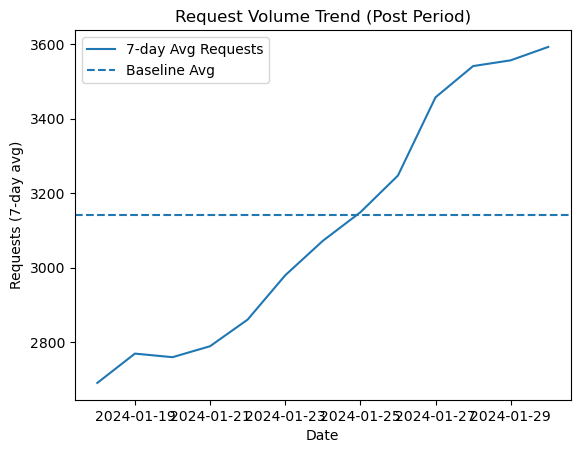

In [16]:
# =========================
# Level 4.X — Visual 1: Volume Trend vs Baseline
# =========================

import matplotlib.pyplot as plt

post_trend = daily_kpis[daily_kpis["period"] == "post"]

plt.figure()
plt.plot(post_trend["created_day"], post_trend["requests_roll"], label="7-day Avg Requests")
plt.axhline(
    baseline_anchors["requests_roll_mean"],
    linestyle="--",
    label="Baseline Avg"
)

plt.title("Request Volume Trend (Post Period)")
plt.xlabel("Date")
plt.ylabel("Requests (7-day avg)")
plt.legend()
plt.show()


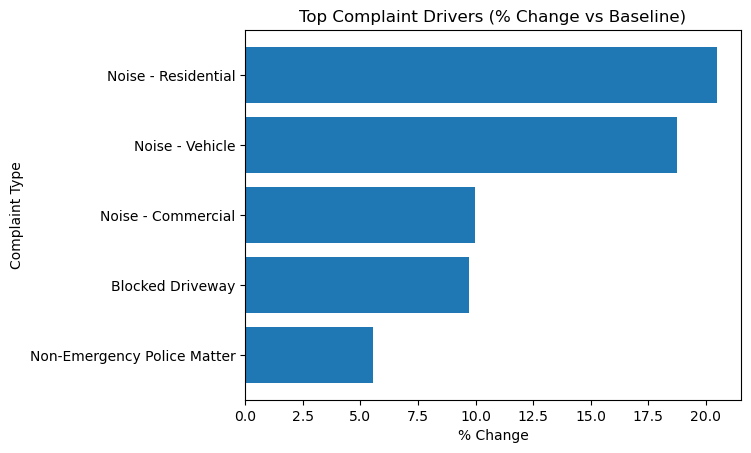

In [17]:
# =========================
# Level 4.X — Visual 2: Driver Categories (% Change)
# =========================

top_drivers = (
    cat_watch
    .dropna(subset=["pct_change"])
    .sort_values("pct_change", ascending=False)
    .head(5)
)

plt.figure()
plt.barh(
    top_drivers["complaint_type"],
    top_drivers["pct_change"] * 100
)

plt.title("Top Complaint Drivers (% Change vs Baseline)")
plt.xlabel("% Change")
plt.ylabel("Complaint Type")
plt.gca().invert_yaxis()
plt.show()
